# Qwen3.5 model size: three matched candidate probes

This notebook compares Qwen3.5-4B, Qwen3.5-9B, and the official
Qwen3.5-27B-GPTQ-Int4 checkpoint on three fixed $N=8$, $K=3$ tasks.

1. **Notebook 05:** the frozen single-call prompt, with Qwen thinking mode
   disabled but a visible concise derivation before `FINAL` permitted.
2. **Notebook 06:** every exact filler-token condition ($F=0\ldots100$,
   five token identities), with an exact `FINAL: ` assistant prefix and
   a forced one-token readout. No text or scratchpad is generated.
3. **Direct held-out:** the notebook-06 prompt at $F=0$ on repeats 2--3,
   again with no generated scratchpad and a forced one-token readout.

Model checkpoints and prompts were fixed before inspecting larger-model
results. The 27B checkpoint is quantized, so size and precision are
inseparable in that comparison; it is not a clean parameter-count scaling
law. Every call uses `enable_thinking=False`.


In [1]:
from __future__ import annotations

import json
import math
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display


def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Run this notebook inside the MATS repository.")


def load_jsonl(path: Path) -> list[dict[str, object]]:
    return [json.loads(line) for line in path.read_text().splitlines() if line.strip()]


def markdown_table(headers: list[str], rows: list[list[object]]) -> None:
    lines = [
        "| " + " | ".join(headers) + " |",
        "| " + " | ".join("---" for _ in headers) + " |",
    ]
    lines.extend("| " + " | ".join(map(str, row)) + " |" for row in rows)
    display(Markdown("\n".join(lines)))


def wilson(successes: int, n: int, z: float = 1.959963984540054) -> tuple[float, float]:
    p = successes / n
    denominator = 1 + z * z / n
    center = (p + z * z / (2 * n)) / denominator
    half = z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / denominator
    return center - half, center + half


def exact_mcnemar(
    left: list[dict[str, object]], right: list[dict[str, object]]
) -> tuple[int, int, float]:
    left_by_id = {str(row["example_id"]): bool(row["correct"]) for row in left}
    right_by_id = {str(row["example_id"]): bool(row["correct"]) for row in right}
    assert left_by_id.keys() == right_by_id.keys()
    left_only = sum(left_by_id[key] and not right_by_id[key] for key in left_by_id)
    right_only = sum(right_by_id[key] and not left_by_id[key] for key in left_by_id)
    discordant = left_only + right_only
    if discordant == 0:
        return left_only, right_only, 1.0
    tail = sum(
        math.comb(discordant, k)
        for k in range(min(left_only, right_only) + 1)
    ) / 2**discordant
    return left_only, right_only, min(1.0, 2 * tail)


REPO_ROOT = find_repo_root()
SIZE_DIR = REPO_ROOT / "artifacts" / "model_size_study"
FILLER_DIR = REPO_ROOT / "artifacts" / "filler_token_probe"
SINGLE_DIR = REPO_ROOT / "artifacts" / "single_call_candidate"
plt.style.use("seaborn-v0_8-whitegrid")

MODEL_ORDER = ["4B", "9B", "27B GPTQ"]
COLORS = {"4B": "#4c78a8", "9B": "#f58518", "27B GPTQ": "#54a24b"}
MODEL_SPECS = {
    "4B": {
        "model_id": "Qwen/Qwen3.5-4B",
        "revision": "851bf6e806efd8d0a36b00ddf55e13ccb7b8cd0a",
        "weights": "BF16",
    },
    "9B": {
        "model_id": "Qwen/Qwen3.5-9B",
        "revision": "c202236235762e1c871ad0ccb60c8ee5ba337b9a",
        "weights": "BF16",
    },
    "27B GPTQ": {
        "model_id": "Qwen/Qwen3.5-27B-GPTQ-Int4",
        "revision": "8f0c09f227ae570e79617c6d9172b59df9c16081",
        "weights": "GPTQ Int4 (dynamic exclusions)",
    },
}


In [2]:
n05_paths = {
    "4B": SINGLE_DIR / "test_system_reason_results.jsonl",
    "9B": SIZE_DIR / "notebook05_9b_results.jsonl",
    "27B GPTQ": SIZE_DIR / "notebook05_27b_results.jsonl",
}
n05_manifest_paths = {
    "4B": SINGLE_DIR / "test_system_reason_manifest.json",
    "9B": SIZE_DIR / "notebook05_9b_manifest.json",
    "27B GPTQ": SIZE_DIR / "notebook05_27b_manifest.json",
}
direct_paths = {
    name: SIZE_DIR / f"direct_{slug}_results.jsonl"
    for name, slug in (("4B", "4b"), ("9B", "9b"), ("27B GPTQ", "27b"))
}
direct_manifest_paths = {
    name: SIZE_DIR / f"direct_{slug}_manifest.json"
    for name, slug in (("4B", "4b"), ("9B", "9b"), ("27B GPTQ", "27b"))
}
filler_paths = {
    "4B": FILLER_DIR / "development_all_fillers_results.jsonl",
    "9B": SIZE_DIR / "notebook06_9b_results.jsonl",
    "27B GPTQ": SIZE_DIR / "notebook06_27b_results.jsonl",
}
filler_manifest_paths = {
    "4B": FILLER_DIR / "development_all_fillers_manifest.json",
    "9B": SIZE_DIR / "notebook06_9b_manifest.json",
    "27B GPTQ": SIZE_DIR / "notebook06_27b_manifest.json",
}

n05 = {name: load_jsonl(path) for name, path in n05_paths.items()}
direct = {name: load_jsonl(path) for name, path in direct_paths.items()}
filler = {name: load_jsonl(path) for name, path in filler_paths.items()}
n05_manifests = {
    name: json.loads(path.read_text()) for name, path in n05_manifest_paths.items()
}
direct_manifests = {
    name: json.loads(path.read_text()) for name, path in direct_manifest_paths.items()
}
filler_manifests = {
    name: json.loads(path.read_text()) for name, path in filler_manifest_paths.items()
}

expected_ids = {str(row["example_id"]) for row in n05["4B"]}
assert len(expected_ids) == 112
n05_reference_messages = {
    str(row["example_id"]): row["messages"] for row in n05["4B"]
}
direct_reference_lengths = {
    str(row["example_id"]): int(row["input_token_count"])
    for row in direct["4B"]
}
filler_reference_lengths = {
    (str(row["example_id"]), str(row["filler"]), int(row["filler_count"])):
    int(row["input_token_count"])
    for row in filler["4B"]
}
for name in MODEL_ORDER:
    assert len(n05[name]) == 112
    assert {str(row["example_id"]) for row in n05[name]} == expected_ids
    assert n05_manifests[name]["variant"]["enable_thinking"] is False
    assert all(bool(row["parse_success"]) for row in n05[name])
    assert all(
        row["messages"] == n05_reference_messages[str(row["example_id"])]
        for row in n05[name]
    )

    assert len(direct[name]) == 112
    assert {str(row["example_id"]) for row in direct[name]} == expected_ids
    assert direct_manifests[name]["protocol"]["enable_thinking"] is False
    assert direct_manifests[name]["protocol"]["generated_reasoning_tokens"] == 0
    assert all(row["enable_thinking"] is False for row in direct[name])
    assert all(
        int(row["input_token_count"])
        == direct_reference_lengths[str(row["example_id"])]
        for row in direct[name]
    )

    assert len(filler[name]) == 28_280
    assert filler_manifests[name]["protocol"]["enable_thinking"] is False
    assert filler_manifests[name]["protocol"]["generated_reasoning_tokens"] == 0
    cells = Counter((row["filler"], row["filler_count"]) for row in filler[name])
    assert len(cells) == 505 and set(cells.values()) == {56}
    baselines = {
        (str(row["example_id"]), str(row["filler"])): int(row["input_token_count"])
        for row in filler[name]
        if int(row["filler_count"]) == 0
    }
    assert all(
        int(row["input_token_count"])
        == baselines[(str(row["example_id"]), str(row["filler"]))]
        + int(row["filler_count"])
        for row in filler[name]
    )
    assert all(
        int(row["input_token_count"])
        == filler_reference_lengths[
            (str(row["example_id"]), str(row["filler"]), int(row["filler_count"]))
        ]
        for row in filler[name]
    )

assert direct_manifests["27B GPTQ"]["model"]["gpu_resident_transformer_layers"] == 64
assert n05_manifests["27B GPTQ"]["model"]["gpu_resident_transformer_layers"] == 64
assert filler_manifests["27B GPTQ"]["model"]["gpu_resident_transformer_layers"] == 64
assert n05_manifests["27B GPTQ"]["model"]["loader_backend"] == "gptqmodel.AUTO"

protocol_reference = filler_manifests["4B"]["protocol"]
for name in MODEL_ORDER:
    protocol = filler_manifests[name]["protocol"]
    assert protocol["fillers"] == protocol_reference["fillers"]
    assert protocol["final_prefix_token_ids"] == [95429, 25, 220]
    assert protocol["answer_token_ids"] == {"2": 17, "7": 22, "=": 28}

print("Matched examples, exact token contracts, complete grids, and no-thinking flags: PASS")


Matched examples, exact token contracts, complete grids, and no-thinking flags: PASS


## Checkpoints and execution

The dense 4B and 9B checkpoints use BF16. The 27B checkpoint uses the
official GPTQ configuration: its dynamic exclusions leave attention,
embeddings, output head, visual tower, and other named modules unquantized.
The automatic GPTQ backend selected Marlin on this RTX 5090. The unused
visual tower and multi-token-prediction tensors remained on CPU; all 64
language layers, embeddings, normalization, and output head were on GPU.


In [3]:
model_rows = []
for name in MODEL_ORDER:
    manifest_model = direct_manifests[name]["model"]
    spec = MODEL_SPECS[name]
    assert manifest_model["model_id"] == spec["model_id"]
    assert manifest_model["resolved_revision"] == spec["revision"]
    model_rows.append(
        [
            name,
            spec["weights"],
            manifest_model["num_hidden_layers"],
            manifest_model["hidden_size"],
            manifest_model["loader_backend"],
            manifest_model["gpu_resident_transformer_layers"] or "all",
            spec["revision"][:12],
        ]
    )
markdown_table(
    ["model", "weights", "layers", "hidden", "loader", "GPU layers", "commit"],
    model_rows,
)


| model | weights | layers | hidden | loader | GPU layers | commit |
| --- | --- | --- | --- | --- | --- | --- |
| 4B | BF16 | 32 | 2560 | transformers | all | 851bf6e806ef |
| 9B | BF16 | 32 | 4096 | transformers | all | c20223623576 |
| 27B GPTQ | GPTQ Int4 (dynamic exclusions) | 64 | 5120 | gptqmodel.AUTO | 64 | 8f0c09f227ae |

## Frozen notebook-05 single-call probe

These calls do **not** use Qwen thinking mode. They do permit a visible
concise derivation, because that is the frozen notebook-05 estimand. The
evaluator parses the last valid `FINAL: 2`, `FINAL: 7`, or `FINAL: TIE`.
Accuracy includes normatively tied examples. Wilson intervals describe
each model separately; exact paired McNemar tests use the shared examples.


In [4]:
n05_summary_rows = []
for name in MODEL_ORDER:
    rows = n05[name]
    correct = sum(bool(row["correct"]) for row in rows)
    low, high = wilson(correct, len(rows))
    non_ties = [row for row in rows if row["normative_absolute"] != "tie"]
    words = [len(str(row["generated_text"]).split()) for row in rows]
    n05_summary_rows.append(
        [
            name,
            f"{correct}/{len(rows)} ({correct / len(rows):.1%})",
            f"[{low:.1%}, {high:.1%}]",
            f"{sum(bool(row['correct']) for row in non_ties)}/{len(non_ties)}",
            f"{np.median(words):.0f}",
            f"{sum(bool(row['parse_success']) for row in rows) / len(rows):.1%}",
            dict(Counter(str(row["predicted_absolute"]) for row in rows)),
        ]
    )
markdown_table(
    ["model", "overall", "95% Wilson", "non-tie", "median words", "parse", "predictions"],
    n05_summary_rows,
)

pair_rows = []
for left, right in (
    ("4B", "9B"),
    ("4B", "27B GPTQ"),
    ("9B", "27B GPTQ"),
):
    left_only, right_only, p_value = exact_mcnemar(n05[left], n05[right])
    pair_rows.append([f"{left} vs {right}", left_only, right_only, f"{p_value:.4f}"])
markdown_table(["pair", "left-only correct", "right-only correct", "exact p"], pair_rows)


| model | overall | 95% Wilson | non-tie | median words | parse | predictions |
| --- | --- | --- | --- | --- | --- | --- |
| 4B | 107/112 (95.5%) | [90.0%, 98.1%] | 58/60 | 140 | 100.0% | {'tie': 51, '2': 33, '7': 28} |
| 9B | 109/112 (97.3%) | [92.4%, 99.1%] | 59/60 | 139 | 100.0% | {'tie': 51, '2': 32, '7': 29} |
| 27B GPTQ | 110/112 (98.2%) | [93.7%, 99.5%] | 60/60 | 186 | 100.0% | {'tie': 50, '2': 33, '7': 29} |

| pair | left-only correct | right-only correct | exact p |
| --- | --- | --- | --- |
| 4B vs 9B | 2 | 4 | 0.6875 |
| 4B vs 27B GPTQ | 2 | 5 | 0.4531 |
| 9B vs 27B GPTQ | 2 | 3 | 1.0000 |

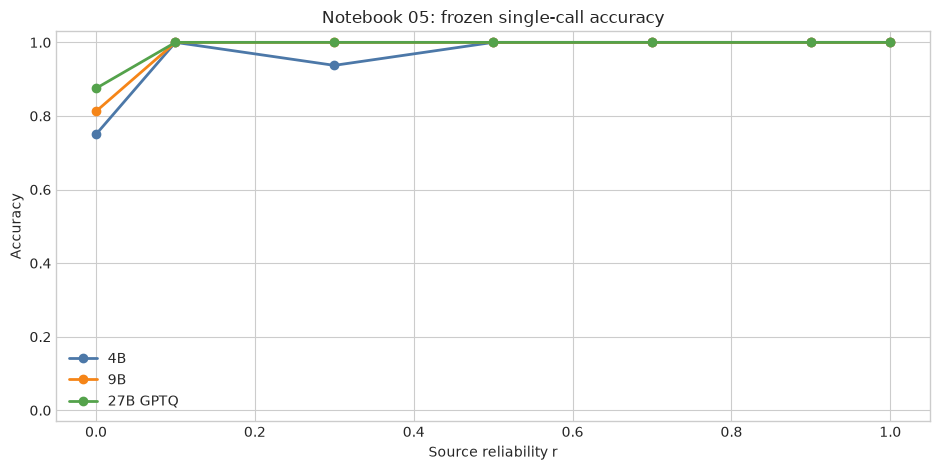

In [5]:
reliabilities = sorted({float(row["reliability"]) for row in n05["4B"]})
fig, ax = plt.subplots(figsize=(9.5, 4.8))
for name in MODEL_ORDER:
    values = []
    for reliability in reliabilities:
        group = [row for row in n05[name] if float(row["reliability"]) == reliability]
        values.append(np.mean([bool(row["correct"]) for row in group]))
    ax.plot(reliabilities, values, marker="o", linewidth=2, label=name, color=COLORS[name])
ax.set(
    xlabel="Source reliability r",
    ylabel="Accuracy",
    ylim=(-0.03, 1.03),
    title="Notebook 05: frozen single-call accuracy",
)
ax.legend()
fig.tight_layout()
path = SIZE_DIR / "notebook05_accuracy_by_reliability.png"
fig.savefig(path, dpi=160, bbox_inches="tight")
plt.show()


## Direct held-out readout: no thinking and no generated reasoning

This is the clean zero-scratchpad test. Each held-out prompt ends at the
exact assistant token prefix `FINAL: ` ($F=0$), then logits for the
single-token surfaces `2`, `7`, and `=` are compared. The model emits no
intervening tokens. Candidate-only accuracy excludes normative ties.


In [6]:
direct_summary_rows = []
for name in MODEL_ORDER:
    rows = direct[name]
    non_ties = [row for row in rows if row["normative_surface"] != "="]
    overall_correct = sum(bool(row["correct"]) for row in rows)
    candidate_correct = sum(bool(row["correct"]) for row in non_ties)
    low, high = wilson(candidate_correct, len(non_ties))
    predictions = Counter(str(row["predicted_surface"]) for row in rows)
    direct_summary_rows.append(
        [
            name,
            f"{overall_correct}/{len(rows)} ({overall_correct / len(rows):.1%})",
            f"{candidate_correct}/{len(non_ties)} ({candidate_correct / len(non_ties):.1%})",
            f"[{low:.1%}, {high:.1%}]",
            dict(predictions),
        ]
    )
markdown_table(
    ["model", "overall", "candidate-only", "candidate 95% Wilson", "predictions"],
    direct_summary_rows,
)

direct_pair_rows = []
for left, right in (
    ("4B", "9B"),
    ("4B", "27B GPTQ"),
    ("9B", "27B GPTQ"),
):
    left_non_ties = [row for row in direct[left] if row["normative_surface"] != "="]
    right_non_ties = [row for row in direct[right] if row["normative_surface"] != "="]
    left_only, right_only, p_value = exact_mcnemar(left_non_ties, right_non_ties)
    direct_pair_rows.append(
        [f"{left} vs {right}", left_only, right_only, f"{p_value:.4f}"]
    )
markdown_table(
    ["pair", "left-only correct", "right-only correct", "exact p"], direct_pair_rows
)


| model | overall | candidate-only | candidate 95% Wilson | predictions |
| --- | --- | --- | --- | --- |
| 4B | 31/112 (27.7%) | 31/60 (51.7%) | [39.3%, 63.8%] | {'2': 54, '7': 58} |
| 9B | 33/112 (29.5%) | 33/60 (55.0%) | [42.5%, 66.9%] | {'7': 65, '2': 47} |
| 27B GPTQ | 38/112 (33.9%) | 38/60 (63.3%) | [50.7%, 74.4%] | {'7': 76, '2': 36} |

| pair | left-only correct | right-only correct | exact p |
| --- | --- | --- | --- |
| 4B vs 9B | 5 | 7 | 0.7744 |
| 4B vs 27B GPTQ | 8 | 15 | 0.2100 |
| 9B vs 27B GPTQ | 6 | 11 | 0.3323 |

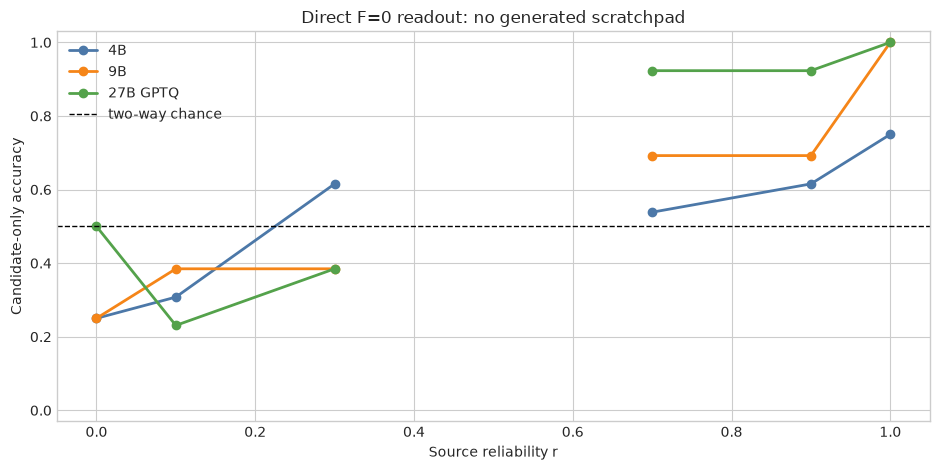

In [7]:
fig, ax = plt.subplots(figsize=(9.5, 4.8))
for name in MODEL_ORDER:
    values = []
    for reliability in reliabilities:
        group = [
            row
            for row in direct[name]
            if float(row["reliability"]) == reliability
            and row["normative_surface"] != "="
        ]
        values.append(np.mean([bool(row["correct"]) for row in group]) if group else np.nan)
    ax.plot(reliabilities, values, marker="o", linewidth=2, label=name, color=COLORS[name])
ax.axhline(0.5, color="black", linestyle="--", linewidth=1, label="two-way chance")
ax.set(
    xlabel="Source reliability r",
    ylabel="Candidate-only accuracy",
    ylim=(-0.03, 1.03),
    title="Direct F=0 readout: no generated scratchpad",
)
ax.legend()
fig.tight_layout()
path = SIZE_DIR / "direct_accuracy_by_reliability.png"
fig.savefig(path, dpi=160, bbox_inches="tight")
plt.show()


## Full notebook-06 exact filler-token sweep

All 505 conditions are descriptive development results. The only
cross-model focal condition is `underscore`, $F=11$, selected by the
original 4B development rule before 9B or 27B results were examined.
It is therefore compared without retuning on the larger checkpoints.


In [8]:
def condition_summaries(rows: list[dict[str, object]]) -> list[dict[str, object]]:
    groups: dict[tuple[str, int], list[dict[str, object]]] = defaultdict(list)
    for row in rows:
        groups[(str(row["filler"]), int(row["filler_count"]))].append(row)
    summaries = []
    for (filler_name, filler_count), group in sorted(groups.items()):
        candidates = [row for row in group if row["normative_surface"] != "="]
        targets_2 = [row for row in candidates if row["normative_surface"] == "2"]
        targets_7 = [row for row in candidates if row["normative_surface"] == "7"]
        summaries.append(
            {
                "filler": filler_name,
                "filler_count": filler_count,
                "candidate_only_accuracy": np.mean([bool(row["correct"]) for row in candidates]),
                "candidate_2_accuracy": np.mean([bool(row["correct"]) for row in targets_2]),
                "candidate_7_accuracy": np.mean([bool(row["correct"]) for row in targets_7]),
                "prediction_counts": dict(Counter(str(row["predicted_surface"]) for row in group)),
            }
        )
    return summaries


filler_conditions = {name: condition_summaries(filler[name]) for name in MODEL_ORDER}
fillers = sorted({str(row["filler"]) for row in filler_conditions["4B"]})
assert fillers == ["comma", "newline", "period", "space", "underscore"]

four_b_means = {
    filler_name: np.mean(
        [
            row["candidate_only_accuracy"]
            for row in filler_conditions["4B"]
            if row["filler"] == filler_name
        ]
    )
    for filler_name in fillers
}
selected_filler = max(fillers, key=four_b_means.get)
selected_curve = {
    int(row["filler_count"]): float(row["candidate_only_accuracy"])
    for row in filler_conditions["4B"]
    if row["filler"] == selected_filler
}
smoothed = {
    f: np.mean([selected_curve[j] for j in range(f - 2, f + 3)])
    for f in range(2, 99)
}
best_smooth = max(smoothed.values())
selected_f = min(f for f, value in smoothed.items() if np.isclose(value, best_smooth))
assert (selected_filler, selected_f) == ("underscore", 11)
print("Original 4B frozen selection reproduced: underscore, F=11")


Original 4B frozen selection reproduced: underscore, F=11


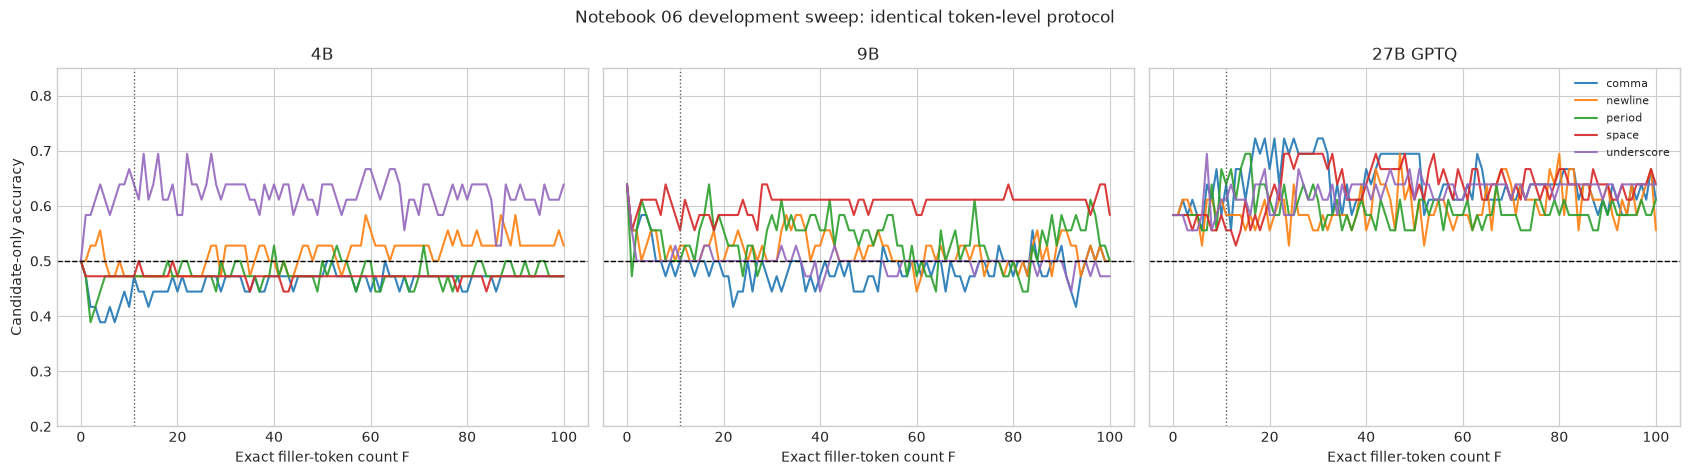

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8), sharex=True, sharey=True)
for ax, name in zip(axes, MODEL_ORDER):
    for filler_name in fillers:
        rows = [
            row for row in filler_conditions[name] if row["filler"] == filler_name
        ]
        ax.plot(
            [row["filler_count"] for row in rows],
            [row["candidate_only_accuracy"] for row in rows],
            linewidth=1.5,
            label=filler_name,
            alpha=0.9,
        )
    ax.axhline(0.5, color="black", linestyle="--", linewidth=1)
    ax.axvline(11, color="#555555", linestyle=":", linewidth=1)
    ax.set(title=name, xlabel="Exact filler-token count F", ylim=(0.2, 0.85))
axes[0].set_ylabel("Candidate-only accuracy")
axes[-1].legend(fontsize=8, ncol=1, loc="best")
fig.suptitle("Notebook 06 development sweep: identical token-level protocol")
fig.tight_layout()
path = SIZE_DIR / "notebook06_model_size_curves.png"
fig.savefig(path, dpi=160, bbox_inches="tight")
plt.show()


In [10]:
mean_rows = []
focal_rows = []
for name in MODEL_ORDER:
    conditions = filler_conditions[name]
    filler_means = {
        filler_name: np.mean(
            [
                row["candidate_only_accuracy"]
                for row in conditions
                if row["filler"] == filler_name
            ]
        )
        for filler_name in fillers
    }
    mean_rows.append(
        [name, f"{np.mean(list(filler_means.values())):.3f}"]
        + [f"{filler_means[filler_name]:.3f}" for filler_name in fillers]
    )
    focal = next(
        row
        for row in conditions
        if row["filler"] == "underscore" and row["filler_count"] == 11
    )
    focal_rows.append(
        [
            name,
            f"{focal['candidate_only_accuracy']:.3f}",
            f"{focal['candidate_2_accuracy']:.3f}",
            f"{focal['candidate_7_accuracy']:.3f}",
            focal["prediction_counts"],
        ]
    )

markdown_table(
    ["model", "all-cell mean"] + fillers,
    mean_rows,
)
display(Markdown("**Frozen 4B-selected condition: underscore, F=11**"))
markdown_table(
    ["model", "candidate-only", "target 2", "target 7", "all predictions"],
    focal_rows,
)


| model | all-cell mean | comma | newline | period | space | underscore |
| --- | --- | --- | --- | --- | --- | --- |
| 4B | 0.508 | 0.460 | 0.513 | 0.475 | 0.472 | 0.621 |
| 9B | 0.530 | 0.488 | 0.519 | 0.538 | 0.605 | 0.499 |
| 27B GPTQ | 0.618 | 0.641 | 0.599 | 0.593 | 0.632 | 0.625 |

**Frozen 4B-selected condition: underscore, F=11**

| model | candidate-only | target 2 | target 7 | all predictions |
| --- | --- | --- | --- | --- |
| 4B | 0.639 | 0.708 | 0.500 | {'2': 42, '7': 14} |
| 9B | 0.500 | 0.417 | 0.667 | {'2': 25, '7': 31} |
| 27B GPTQ | 0.611 | 0.750 | 0.333 | {'2': 39, '7': 17} |

## Interpretation guardrails

- Notebook 05 measures performance with a visible, model-generated concise
  derivation. It disables Qwen thinking mode, but it is not a no-reasoning
  or zero-scratchpad condition.
- The direct and filler probes generate zero reasoning tokens. They measure
  the local one-token readout after an exact assistant prefix, which can be
  dominated by answer-surface bias even when the same model solves the task
  with a visible derivation.
- The 112 held-out examples yield only 60 non-tie candidate decisions.
  Small percentage differences have broad paired uncertainty and should not
  be read as a monotonic scaling trend without the paired counts.
- The 27B point changes parameter count, precision, and low-level kernel.
  It answers whether this deployable quantized checkpoint works here, not
  what an otherwise identical 27B BF16 model would do.
- The 505 notebook-06 cells are correlated repeated measurements of the
  same 56 examples, not 28,280 independent trials. Curves and cell means are
  descriptive; no larger-model filler was selected post hoc.


In [11]:
n05_accuracies = {
    name: np.mean([bool(row["correct"]) for row in n05[name]]) for name in MODEL_ORDER
}
direct_candidate = {
    name: np.mean(
        [
            bool(row["correct"])
            for row in direct[name]
            if row["normative_surface"] != "="
        ]
    )
    for name in MODEL_ORDER
}
collapsed = {
    name: len({str(row["predicted_surface"]) for row in direct[name]}) == 1
    for name in MODEL_ORDER
}
print("Notebook-05 accuracy:", {name: round(value, 4) for name, value in n05_accuracies.items()})
print("Direct candidate-only accuracy:", {name: round(value, 4) for name, value in direct_candidate.items()})
print("Single-surface direct collapse:", collapsed)
print(
    "Main contrast: the visible-derivation probe is near ceiling for every model, while "
    "the direct no-scratchpad readout improves numerically but retains broad paired "
    "uncertainty and strong answer-surface imbalance. Filler effects remain highly "
    "identity- and depth-dependent."
)


Notebook-05 accuracy: {'4B': np.float64(0.9554), '9B': np.float64(0.9732), '27B GPTQ': np.float64(0.9821)}
Direct candidate-only accuracy: {'4B': np.float64(0.5167), '9B': np.float64(0.55), '27B GPTQ': np.float64(0.6333)}
Single-surface direct collapse: {'4B': False, '9B': False, '27B GPTQ': False}
Main contrast: the visible-derivation probe is near ceiling for every model, while the direct no-scratchpad readout improves numerically but retains broad paired uncertainty and strong answer-surface imbalance. Filler effects remain highly identity- and depth-dependent.
